In [1]:
# --- Imports ---
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt

from data_loader import DataLoader

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
loader = DataLoader(data_dir="../data")
print(f"Total aligned trials: {len(loader)}")

Found 2160 signal files in ../data\MI CSV
[DataLoader] found 2400 labels and 2160 signal files.
DataLoader: Dropping last 240 extra labels to align with signal files.
[DataLoader] successfully aligned 2160 EEG trials with labels.
Total aligned trials: 2160


## Notebook 2 Goals

**Part A — Artifact rejection rule (finishing Person 1's Day 1 work)**
- Quantify rejection % under a few different thresholds
- Propose one clear rejection rule, backed by evidence

**Part B — PSD / ERD analysis (Person 2, the critical check)**
- Full LEFT vs RIGHT PSD comparison on C3/C4
- Focus on 8–30 Hz — confirm or deny ERD
- Answers: does this data actually show a usable LEFT/RIGHT difference?

⚠️ Note: sampling rate is still unconfirmed . All PSD
frequency-axis values in this notebook use fs_placeholder = 250 and are
NOT final until confirmed with the instructor.

In [3]:
artifact_df = pd.read_csv("../data/artifact_flags.csv")
jump_df = pd.read_csv("../data/jump_flags.csv")
print(artifact_df.shape)
print(jump_df.shape)

(8640, 8)
(8640, 3)


In [4]:
artifact_df.describe()

,trial_id,std,peak_to_peak
count,8640.000000,8640.000000,8640.000000
mean,1080.500000,1430.032197,4926.987650
std,623.574311,2363.604846,8691.613058
min,1.000000,15.599627,102.468750
25%,540.750000,313.018241,1116.414062
50%,1080.500000,707.337550,2406.312500
75%,1620.250000,1689.833858,5373.273438
max,2160.000000,48779.695254,186254.250000


,iqr_multiplier,flagged_trials,pct_rejected
0,1.5,236,10.93
1,2.0,212,9.81
2,2.5,194,8.98
3,3.0,187,8.66
4,4.0,169,7.82


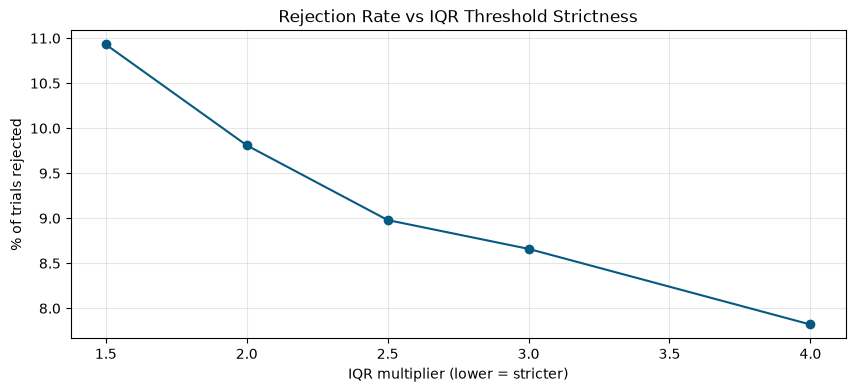

In [5]:
# --- Test multiple IQR multipliers, see how rejection % changes ---
channels = ["FZ", "C3", "CZ", "C4"]
multipliers = [1.5, 2.0, 2.5, 3.0, 4.0]

results = []

for mult in multipliers:
    artifact_df["flag_temp"] = False
    for ch in channels:
        mask = artifact_df["channel"] == ch
        values = artifact_df.loc[mask, "peak_to_peak"]
        q1, q3 = values.quantile(0.25), values.quantile(0.75)
        iqr = q3 - q1
        upper = q3 + mult * iqr
        artifact_df.loc[mask & (artifact_df["peak_to_peak"] > upper), "flag_temp"] = True

    flagged_trials = artifact_df[artifact_df["flag_temp"]]["trial_id"].nunique()
    pct = flagged_trials / loader.valid_manifest["trial_id"].nunique() * 100

    results.append({"iqr_multiplier": mult, "flagged_trials": flagged_trials, "pct_rejected": round(pct, 2)})

results_df = pd.DataFrame(results)
display(results_df)

plt.plot(results_df["iqr_multiplier"], results_df["pct_rejected"], marker="o", color="#065A82")
plt.title("Rejection Rate vs IQR Threshold Strictness")
plt.xlabel("IQR multiplier (lower = stricter)")
plt.ylabel("% of trials rejected")
plt.grid(alpha=0.3)
plt.show()

artifact_df.drop(columns="flag_temp", inplace=True)

## Saving the outliers trials in a csv for further cleaning

In [6]:
# --- Rebuild the 57-trial high-confidence rejection list in this notebook ---

# Re-apply the same 3x IQR flagging (peak-to-peak) on the loaded artifact_df
artifact_df["extreme_variability"] = False
for ch in channels:
    mask = artifact_df["channel"] == ch
    values = artifact_df.loc[mask, "peak_to_peak"]
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 3 * iqr
    artifact_df.loc[mask & (artifact_df["peak_to_peak"] > upper), "extreme_variability"] = True

# Re-apply the same 3x IQR flagging (max jump) on the loaded jump_df
jump_df["flagged"] = False
for ch in channels:
    mask = jump_df["channel"] == ch
    values = jump_df.loc[mask, "max_jump"]
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 3 * iqr
    jump_df.loc[mask & (jump_df["max_jump"] > upper), "flagged"] = True

# Get the overlap — trials flagged by BOTH methods
peak_flagged_ids = set(artifact_df[artifact_df["extreme_variability"]]["trial_id"])
jump_flagged_ids = set(jump_df[jump_df["flagged"]]["trial_id"])

rejection_list = sorted(peak_flagged_ids & jump_flagged_ids)

print(f"Final rejection candidates: {len(rejection_list)} trials")
print(f"That's {len(rejection_list) / loader.valid_manifest['trial_id'].nunique() * 100:.1f}% of the dataset")

# Save for use in preprocessing.py next week
rejection_df = pd.DataFrame({"trial_id": rejection_list})
rejection_df.to_csv("../data/rejection_candidates.csv", index=False)

rejection_df.count()

Final rejection candidates: 165 trials
That's 7.6% of the dataset


trial_id    165
dtype: int64

## PSD

In [7]:
# --- Compute PSD for every trial on C3 and C4, grouped by label ---
fs_placeholder = 250  

def compute_psd(signal, fs=fs_placeholder):
    freqs, psd = welch(signal, fs=fs, nperseg=256)
    return freqs, psd

psd_records = {"C3": {"left": [], "right": []}, "C4": {"left": [], "right": []}}
freqs_ref = None

for i in range(len(loader)):
    signal_df, label = loader.load_trial(i)
    for ch in ["C3", "C4"]:
        freqs, psd = compute_psd(signal_df[ch].values)
        psd_records[ch][label].append(psd)
        if freqs_ref is None:
            freqs_ref = freqs

print("Done computing PSD for all trials.")

Done computing PSD for all trials.


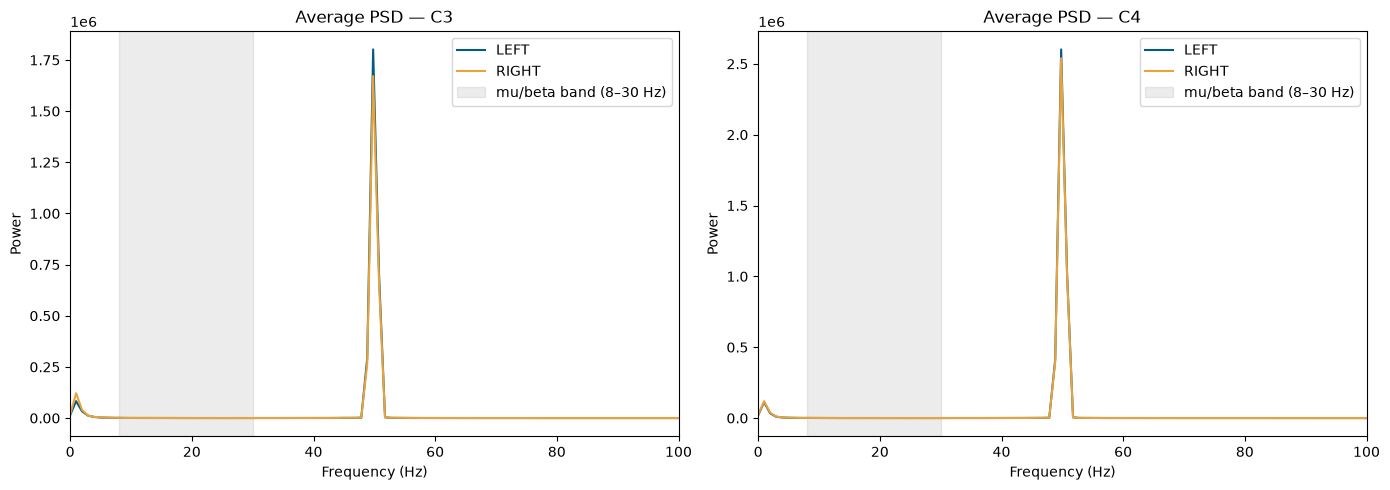

In [12]:
# --- Average PSD across all trials, per label, per channel ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ch in zip(axes, ["C3", "C4"]):
    left_avg = np.mean(psd_records[ch]["left"], axis=0)
    right_avg = np.mean(psd_records[ch]["right"], axis=0)

    ax.plot(freqs_ref, left_avg, label="LEFT", color="#065A82")
    ax.plot(freqs_ref, right_avg, label="RIGHT", color="#E8A33D")
    ax.axvspan(8, 30, color="gray", alpha=0.15, label="mu/beta band (8–30 Hz)")
    ax.set_title(f"Average PSD — {ch}")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.set_xlim(0, 100)
    ax.legend()

plt.tight_layout()
plt.show()

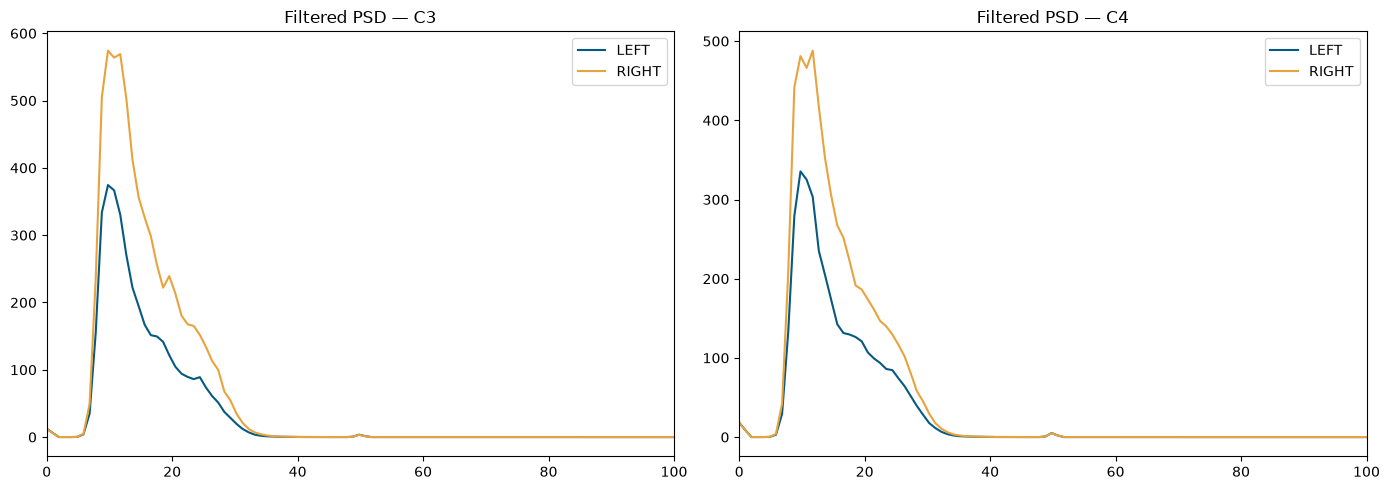

In [13]:
def bandpass_filter(signal, low=8, high=30, fs=fs_placeholder, order=4):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, signal)

psd_filtered = {"C3": {"left": [], "right": []}, "C4": {"left": [], "right": []}}

for i in range(len(loader)):
    signal_df, label = loader.load_trial(i)
    for ch in ["C3", "C4"]:
        filtered_signal = bandpass_filter(signal_df[ch].values)
        freqs, psd = welch(filtered_signal, fs=fs_placeholder, nperseg=256)
        psd_filtered[ch][label].append(psd)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ch in zip(axes, ["C3", "C4"]):
    left_avg = np.mean(psd_filtered[ch]["left"], axis=0)
    right_avg = np.mean(psd_filtered[ch]["right"], axis=0)
    ax.plot(freqs, left_avg, label="LEFT", color="#065A82")
    ax.plot(freqs, right_avg, label="RIGHT", color="#E8A33D")
    ax.set_title(f"Filtered PSD — {ch}")
    ax.set_xlim(0, 100)
    ax.legend()
plt.tight_layout()
plt.show()

In [10]:
band_power_records_filtered = []

for i in range(len(loader)):
    signal_df, label = loader.load_trial(i)
    for ch in ["C3", "C4"]:
        filtered_signal = bandpass_filter(signal_df[ch].values)
        freqs, psd = welch(filtered_signal, fs=fs_placeholder, nperseg=256)
        band_mask = (freqs >= 8) & (freqs <= 30)
        band_power = psd[band_mask].mean()
        band_power_records_filtered.append({
            "trial_id": loader.valid_manifest.iloc[i]["trial_id"],
            "label": label, "channel": ch, "band_power": band_power
        })

band_power_df_filtered = pd.DataFrame(band_power_records_filtered)
summary_filtered = band_power_df_filtered.groupby(["channel", "label"])["band_power"].mean().unstack()
print(summary_filtered)

label          left       right
channel                        
C3       160.833421  280.565950
C4       147.080166  237.501755


In [11]:
# --- T-test on FILTERED band power ---
from scipy.stats import ttest_ind

for ch in ["C3", "C4"]:
    left_vals = band_power_df_filtered[(band_power_df_filtered["channel"] == ch) & (band_power_df_filtered["label"] == "left")]["band_power"]
    right_vals = band_power_df_filtered[(band_power_df_filtered["channel"] == ch) & (band_power_df_filtered["label"] == "right")]["band_power"]

    t_stat, p_val = ttest_ind(left_vals, right_vals)
    print(f"{ch}: t={t_stat:.3f}, p={p_val:.5f}")

C3: t=-1.598, p=0.11011
C4: t=-2.127, p=0.03352
